In [3]:
import torch
from torch import nn
from d2l import torch as d2l
import torchvision

In [4]:
net = nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5,padding=2),nn.Sigmoid(),
    nn.AvgPool2d(2,2),
    nn.Conv2d(6,16,kernel_size=5),nn.Sigmoid(),
    nn.AvgPool2d(2,2),
    nn.Flatten(),
    nn.Linear(16*5*5,120),nn.Sigmoid(),
    nn.Linear(120,84),nn.Sigmoid(),
    nn.Linear(84,10)
)

下面将一个大小为28*28的黑白图像通过这个网络

In [5]:
X = torch.rand(size=(1,1,28,28))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t',X.shape)

Conv2d output shape:	 torch.Size([1, 6, 28, 28])
Sigmoid output shape:	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape:	 torch.Size([1, 6, 14, 14])
Conv2d output shape:	 torch.Size([1, 16, 10, 10])
Sigmoid output shape:	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape:	 torch.Size([1, 16, 5, 5])
Flatten output shape:	 torch.Size([1, 400])
Linear output shape:	 torch.Size([1, 120])
Sigmoid output shape:	 torch.Size([1, 120])
Linear output shape:	 torch.Size([1, 84])
Sigmoid output shape:	 torch.Size([1, 84])
Linear output shape:	 torch.Size([1, 10])


模型训练

In [6]:
batch_size = 256
dataset = torchvision.datasets.FashionMNIST(root='data',train=True,transform=torchvision.transforms.ToTensor(),download=True)
train_iter = torch.utils.data.DataLoader(dataset,batch_size=batch_size,shuffle=True)
test_data = torchvision.datasets.FashionMNIST(root='data',train=False,transform=torchvision.transforms.ToTensor(),download=True)
test_iter = torch.utils.data.DataLoader(test_data,batch_size=batch_size,shuffle=False)


In [ ]:
def train_ch6(net,train_iter,test_iter,num_epochs,lr,device):
    def init_weights(m):
        # 只对可学习权重的层做 Xavier 初始化（Linear/Conv2d）
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    # 递归遍历 net 的所有子层，并调用 init_weights
    net.apply(init_weights)
    print('training on',device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(),lr=lr)
    loss = nn.CrossEntropyLoss()
    # 训练可视化器：横轴 epoch，三条曲线分别是训练损失/训练精度/测试精度
    animator = d2l.Animator(xlabel='epoch',xlim=[1,num_epochs],legend=['train loss','train acc','test acc'])
    # timer 统计耗时，num_batches 是每个 epoch 的 batch 数
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        net.train()
        # 累加器三个槽位：总损失、总正确数、总样本数
        metric = d2l.Accumulator(3)
        # enumerate 会同时给出批次下标 i 和当前批数据 (X, y)
        for i,(X,y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X,y = X.to(device),y.to(device)
            y_hat = net(X)
            l = loss(y_hat,y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                # l 通常是 batch 平均损失，这里乘 batch_size 转成“总损失”再累加
                metric.add(l*X.shape[0],d2l.accuracy(y_hat,y),X.shape[0])
            timer.stop()
            train_l = metric[0]/metric[2]
            train_acc = metric[1]/metric[2]
            # 每个 epoch 大约记录 5 次训练曲线，且保证最后一个 batch 一定记录
            if (i+1)%max(num_batches//5,1) == 0 or i == num_batches-1:
                # x 轴用小数 epoch（如 3.6），这里只更新训练损失和训练精度
                animator.add(epoch+(i+1)/num_batches,(train_l,train_acc,None))
        test_acc = d2l.evaluate_accuracy(net,test_iter)
        # 每个 epoch 结束后再更新一次测试精度曲线
        animator.add(epoch+1,(None,None,test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2]*num_epochs/timer.sum():.1f} examples/sec on {str(device)}')

loss 0.459, train acc 0.829, test acc 0.820
11812.2 examples/sec on cpu


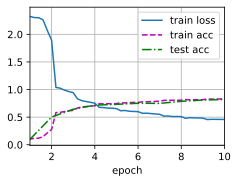

In [10]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())